In [29]:
import time
import random
import datetime
import statistics
import joblib 
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.linear_model import (
    LinearRegression,
    RANSACRegressor,
    TheilSenRegressor,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge
)

from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import (
    explained_variance_score,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)
from IPython.display import Image

In [30]:
df = pd.read_csv('electricity_cost_dataset.csv')
len(df) 
df.head()

,site area,structure type,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0


In [31]:
data = df.copy()
data.columns

Index(['site area', 'structure type', 'water consumption', 'recycling rate', 'utilisation rate',
       'air qality index', 'issue reolution time', 'resident count', 'electricity cost'],
      dtype='object')

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site area             10000 non-null  int64  
 1   structure type        10000 non-null  object 
 2   water consumption     10000 non-null  float64
 3   recycling rate        10000 non-null  int64  
 4   utilisation rate      10000 non-null  int64  
 5   air qality index      10000 non-null  int64  
 6   issue reolution time  10000 non-null  int64  
 7   resident count        10000 non-null  int64  
 8   electricity cost      10000 non-null  float64
dtypes: float64(2), int64(6), object(1)
memory usage: 703.3+ KB


In [33]:
data.describe()

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,2757.775,3494.057,49.598,64.842,99.469,36.403,85.573,2837.845
std,1293.060,2076.181,23.430,20.433,58.015,20.624,107.876,1106.997
min,501.000,1000.000,10.000,30.000,0.000,1.000,0.000,500.000
25%,1624.000,1779.000,29.750,47.000,49.000,19.000,0.000,1954.000
50%,2773.500,3047.500,49.000,65.000,100.000,36.000,39.000,2760.000
75%,3874.000,4811.000,70.000,83.000,150.000,54.000,142.000,3632.000
max,5000.000,10894.000,90.000,100.000,200.000,72.000,489.000,6446.000


In [34]:
data.shape

(10000, 9)

In [35]:
data.duplicated().sum()

np.int64(0)

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site area             10000 non-null  int64  
 1   structure type        10000 non-null  object 
 2   water consumption     10000 non-null  float64
 3   recycling rate        10000 non-null  int64  
 4   utilisation rate      10000 non-null  int64  
 5   air qality index      10000 non-null  int64  
 6   issue reolution time  10000 non-null  int64  
 7   resident count        10000 non-null  int64  
 8   electricity cost      10000 non-null  float64
dtypes: float64(2), int64(6), object(1)
memory usage: 703.3+ KB


In [37]:
data.head()

,site area,structure type,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0


In [38]:
data["structure type"].value_counts()

structure type
Residential    3939
Commercial     3005
Mixed-use      2052
Industrial     1004
Name: count, dtype: int64

In [39]:
data['structure type'].dtype
data['structure type'].unique()

array(['Mixed-use', 'Residential', 'Commercial', 'Industrial'],
      dtype=object)

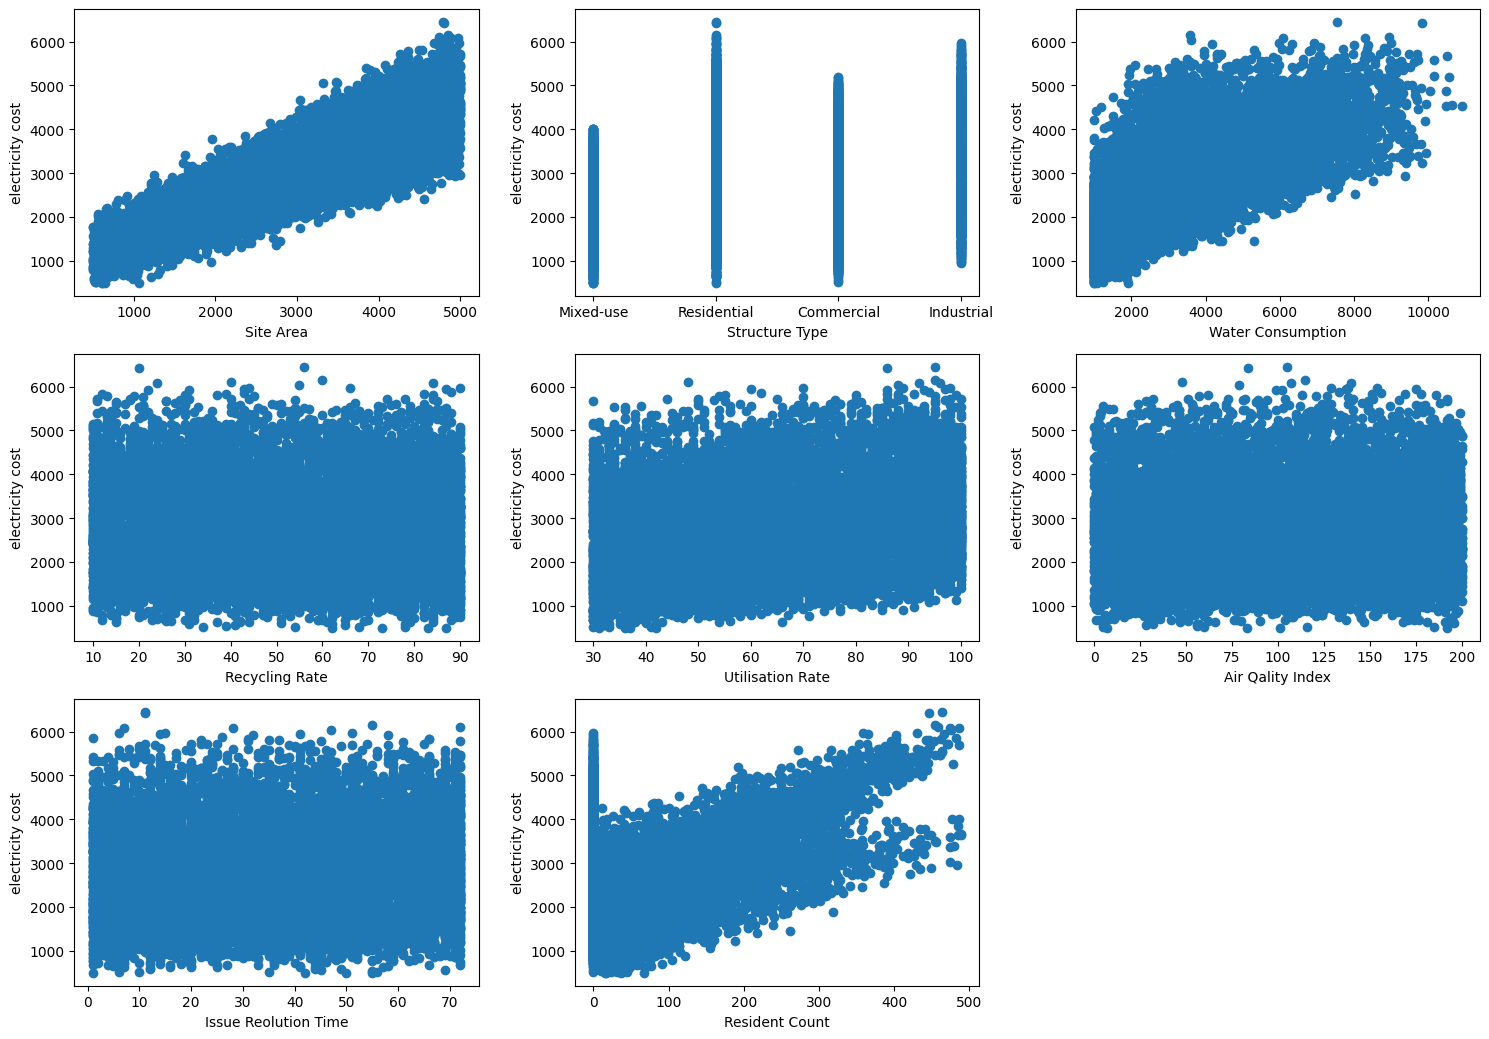

In [40]:
plt.figure(figsize=(15, 10.5))

for idx, feature in enumerate(data.columns[:-1], start=1):
    plt.subplot(3, 3, idx)
    plt.scatter(data[feature], data['electricity cost'])
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel('electricity cost')

plt.tight_layout()
plt.show()

## Relationship Between Features and Concrete Strength

The following table summarizes the insights obtained from the scatter plots between different features and **Concrete Strength**.

| Feature | Observed Relationship with Concrete Strength | Interpretation |
|-------|---------------------------------------------|----------------|
| **Site Area** | Strong positive linear relationship | As site area increases, concrete strength generally increases. Larger sites likely involve more robust construction requirements. |
| **Structure Type** | Categorical separation visible | Different structure types (Mixed-use, Residential, Commercial, Industrial) show distinct strength distributions, indicating structure type influences concrete strength. |
| **Water Consumption** | Moderate positive trend with high variance | Higher water consumption is associated with higher concrete strength, but variability suggests other factors also play a role. |
| **Recycling Rate** | No clear trend | Concrete strength appears independent of recycling rate; points are uniformly scattered. |
| **Utilisation Rate** | Weak to moderate positive relationship | Increased utilisation rate slightly correlates with higher concrete strength, possibly due to better resource optimization. |
| **Air Quality Index** | No significant relationship | Concrete strength does not show dependency on air quality index. |
| **Issue Resolution Time** | No clear relationship | Variations in issue resolution time do not significantly affect concrete strength. |
| **Resident Count** | Strong positive relationship | Higher resident count correlates with higher concrete strength, indicating stronger materials are used for denser populations. |

## Overall Observations

- **Strong predictors** of concrete strength:  
  - Site Area  
  - Resident Count  

- **Moderate influence**:  
  - Water Consumption  
  - Utilisation Rate  

- **Weak or negligible influence**:  
  - Recycling Rate  
  - Air Quality Index  
  - Issue Resolution Time  

These insights suggest that structural and scale-related features have a greater impact on concrete strength than environmental or operational factors.


In [41]:
data.columns

Index(['site area', 'structure type', 'water consumption', 'recycling rate', 'utilisation rate',
       'air qality index', 'issue reolution time', 'resident count', 'electricity cost'],
      dtype='object')

In [42]:
import pandas as pd

features = ['site area', 'structure type', 'water consumption', 'recycling rate', 
            'utilisation rate', 'air qality index', 'issue reolution time', 'resident count' , 'electricity cost']

# One-hot encode 'structure type'
data_encoded = pd.get_dummies(data[features], columns=['structure type'], drop_first=True)

# Now calculate correlations
correlations = data_encoded.corr()

# Optional: set display options
pd.set_option('display.width', 100)
pd.set_option('display.precision', 3)

print(correlations)


                            site area  water consumption  recycling rate  utilisation rate  \
site area                       1.000          7.454e-01           0.007         1.968e-02   
water consumption               0.745          1.000e+00           0.007         8.711e-03   
recycling rate                  0.007          6.977e-03           1.000        -2.235e-02   
utilisation rate                0.020          8.711e-03          -0.022         1.000e+00   
air qality index               -0.004          9.288e-04          -0.011        -8.747e-03   
issue reolution time            0.008          7.786e-03          -0.006        -7.952e-04   
resident count                  0.360          2.813e-01          -0.009         1.242e-02   
electricity cost                0.874          6.988e-01          -0.013         2.072e-01   
structure type_Industrial      -0.008         -1.370e-02           0.006         2.613e-03   
structure type_Mixed-use        0.018          2.704e-03    

In [43]:
data.head()
data_encoded.head()

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost,structure type_Industrial,structure type_Mixed-use,structure type_Residential
0,1360,2519.0,69,52,188,1,72,1420.0,False,True,False
1,4272,2324.0,50,76,165,65,261,3298.0,False,True,False
2,3592,2701.0,20,94,198,39,117,3115.0,False,True,False
3,966,1000.0,13,60,74,3,35,1575.0,False,False,True
4,4926,5990.0,23,65,32,57,185,4301.0,False,False,True


## Correlation Analysis Between Input Features

The following observations are drawn from the correlation matrix of the dataset. Correlation values range from **-1 to +1**, where values close to ±1 indicate strong relationships and values close to 0 indicate weak or no linear relationship.

### Key Correlation Insights

| Feature Pair | Correlation Value | Interpretation |
|-------------|------------------|----------------|
| **Site Area & Water Consumption** | **0.745** | Strong positive correlation, indicating that larger site areas tend to consume more water. |
| **Site Area & Resident Count** | **0.360** | Moderate positive relationship; larger sites generally accommodate more residents. |
| **Water Consumption & Resident Count** | **0.281** | Moderate positive correlation; higher resident count leads to increased water usage. |
| **Resident Count & Structure Type (Residential)** | **0.432** | Strong association showing residential structures typically have higher resident populations. |
| **Resident Count & Structure Type (Industrial)** | **-0.265** | Negative correlation; industrial structures generally have fewer residents. |
| **Resident Count & Structure Type (Mixed-use)** | **0.264** | Moderate positive relationship indicating mixed-use buildings house residents as well. |

### Weak or Negligible Correlations

| Feature | Observation |
|-------|-------------|
| Recycling Rate | Shows near-zero correlation with most variables, indicating independence from structural and operational features. |
| Utilisation Rate | Very weak correlations across all features, suggesting minimal linear dependency. |
| Air Quality Index | Almost no correlation with other variables, indicating environmental quality is largely independent in this dataset. |
| Issue Resolution Time | Negligible correlations, implying operational delays do not influence structural or usage-related variables. |

### Structure Type Relationships

- **Negative correlations among structure types** (e.g., Industrial vs Residential: -0.269) occur due to **one-hot encoding**, where an increase in one category implies the absence of another.
- Structure type variables mainly influence **resident count**, rather than physical or environmental parameters.

### Overall Observations

- **Strongest correlation observed**:  
  - Site Area and Water Consumption (**0.745**)

- **Moderate correlations** exist between:  
  - Site Area and Resident Count  
  - Water Consumption and Resident Count  

- **Most features are weakly correlated**, suggesting:
  - Low multicollinearity  
  - Suitability for linear and non-linear machine learning models  

### Conclusion

The correlation matrix indicates that **scale-related features** (site area, water consumption, resident count) are interrelated, while **environmental and operational features** behave independently. This is favorable for predictive modeling, as it reduces redundancy among input features.


In [44]:
# Make sure your target column exists
target = 'electricity cost'

# One-hot encode categorical columns (like you did)
data_encoded = pd.get_dummies(data, columns=['structure type'], drop_first=True)

# Include the target in the encoded DataFrame
data_encoded[target] = data[target]

# Compute correlation of all features with the target
correlation_with_target = data_encoded.corr()[target].sort_values(ascending=False)

print(correlation_with_target)



electricity cost              1.000
site area                     0.874
water consumption             0.699
resident count                0.362
utilisation rate              0.207
structure type_Industrial     0.169
structure type_Residential    0.113
issue reolution time          0.042
air qality index              0.017
recycling rate               -0.013
structure type_Mixed-use     -0.245
Name: electricity cost, dtype: float64


## Conclusion (Correlation with Target Variable: Electricity Cost)

The correlation analysis indicates that **electricity cost** is most strongly influenced by **site area (r = 0.874)** and **water consumption (r = 0.699)**, showing strong positive linear relationships. **Resident count (r = 0.362)** and **utilisation rate (r = 0.207)** have moderate positive correlations with electricity cost. **Industrial (r = 0.169)** and **Residential (r = 0.113)** structure types show weak positive correlations, while **Mixed-use structures (r = -0.245)** exhibit a moderate negative correlation. **Recycling rate, air quality index, and issue resolution time** have near-zero correlations, indicating no meaningful linear relationship with electricity cost.


In [45]:
# List of columns to remove
cols_to_drop = ['recycling rate', 'air qality index', 'issue reolution time']

# Drop them from your encoded dataframe
data_final = data_encoded.drop(columns=cols_to_drop)

# Verify the result
print(data_final.columns)

Index(['site area', 'water consumption', 'utilisation rate', 'resident count', 'electricity cost',
       'structure type_Industrial', 'structure type_Mixed-use', 'structure type_Residential'],
      dtype='object')


In [46]:
from sklearn.model_selection import train_test_split
import pandas as pd

def prepare_and_split_data(df_final, target_col, test_size=0.2, random_state=42):

    X = df_final.drop(columns=[target_col])
    y = df_final[target_col]
    
    # 4. Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    return X_train, X_test, y_train, y_test


In [47]:
data_final.head()

,site area,water consumption,utilisation rate,resident count,electricity cost,structure type_Industrial,structure type_Mixed-use,structure type_Residential
0,1360,2519.0,52,72,1420.0,False,True,False
1,4272,2324.0,76,261,3298.0,False,True,False
2,3592,2701.0,94,117,3115.0,False,True,False
3,966,1000.0,60,35,1575.0,False,False,True
4,4926,5990.0,65,185,4301.0,False,False,True


In [48]:
data_final.columns
data_final.dtypes

site area                       int64
water consumption             float64
utilisation rate                int64
resident count                  int64
electricity cost              float64
structure type_Industrial        bool
structure type_Mixed-use         bool
structure type_Residential       bool
dtype: object

## __Calculating Linear Regression__

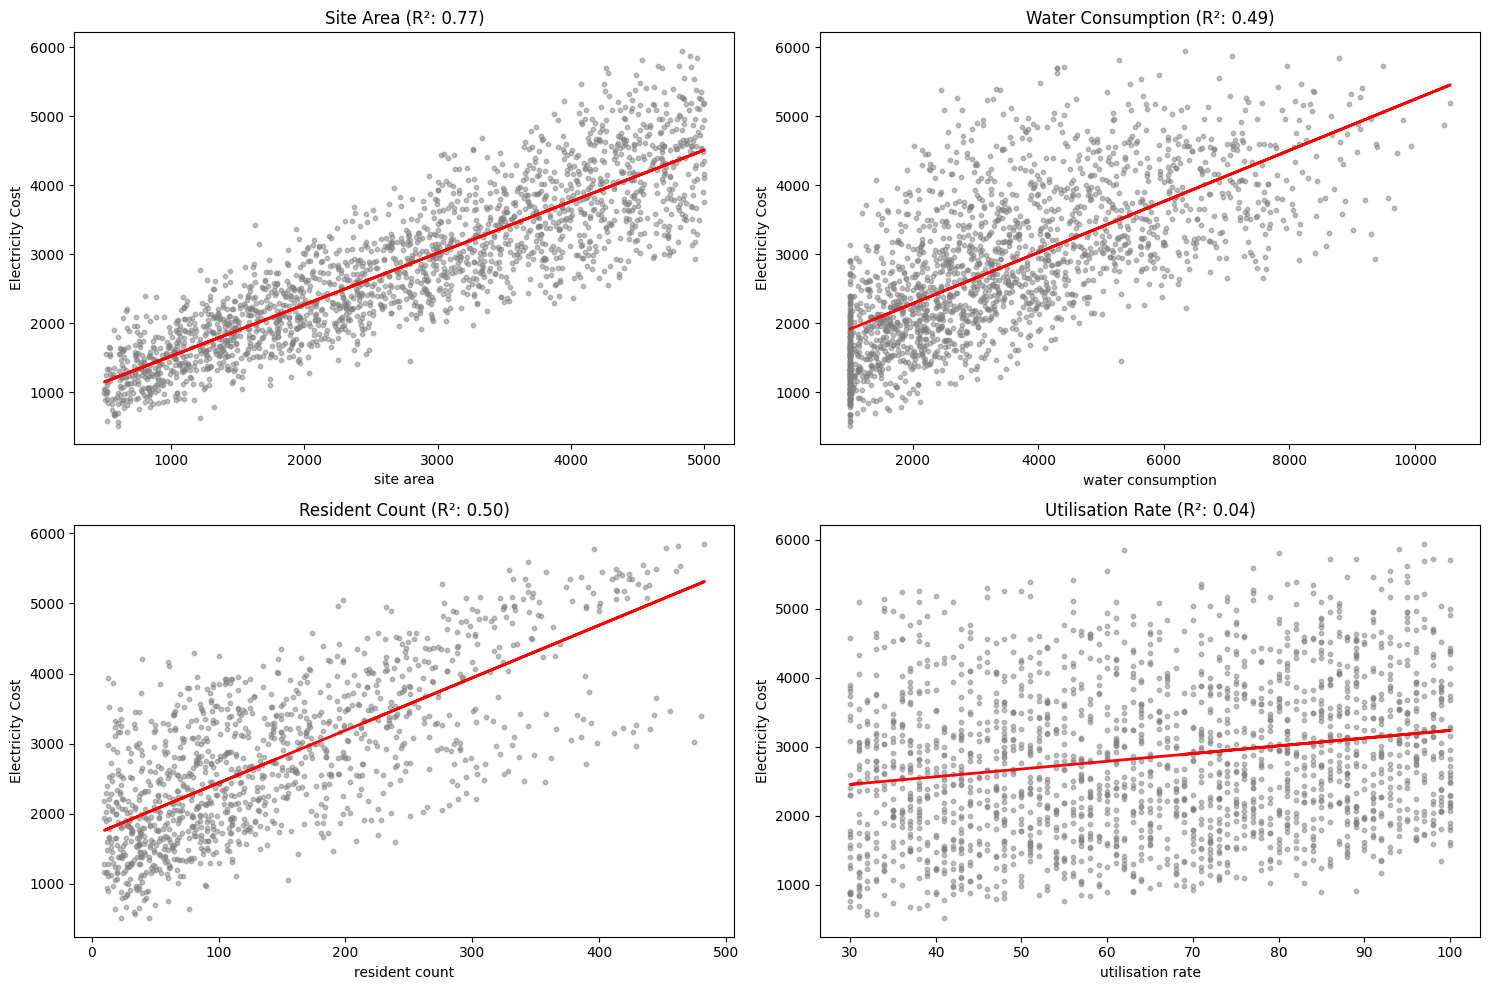

In [49]:
# Define the features we want to visualize (the ones not dropped)
features_to_plot = ['site area', 'water consumption', 'resident count', 'utilisation rate']

plt.figure(figsize=(15, 10))
plot_count = 1

for feature in features_to_plot:
    # 1. Prepare small subset for this specific feature
    data_tr = data_final[['electricity cost', feature]].dropna()
    data_tr = data_tr[data_tr[feature] != 0] # Remove zeros

    # 2. Split using your function
    # Correct order: X_train, X_test, y_train, y_test
    X_train, X_test, y_train, y_test = prepare_and_split_data(data_tr, 'electricity cost')

    # 3. Model Training
    regr = LinearRegression()
    regr.fit(X_train, y_train)

    # 4. Predictions
    y_pred = regr.predict(X_test)

    # 5. Plotting
    plt.subplot(2, 2, plot_count) # Adjusted to 2x2 since we have 4 features
    plt.scatter(X_test, y_test, color='gray', alpha=0.5, s=10)
    plt.plot(X_test, y_pred, color='red', linewidth=2)
    
    plt.title(f"{feature.title()} (R²: {r2_score(y_test, y_pred):.2f})")
    plt.xlabel(feature)
    plt.ylabel('Electricity Cost')
    

    plot_count += 1

plt.tight_layout()
plt.show()

__Calculating Multiple Linear Regression__

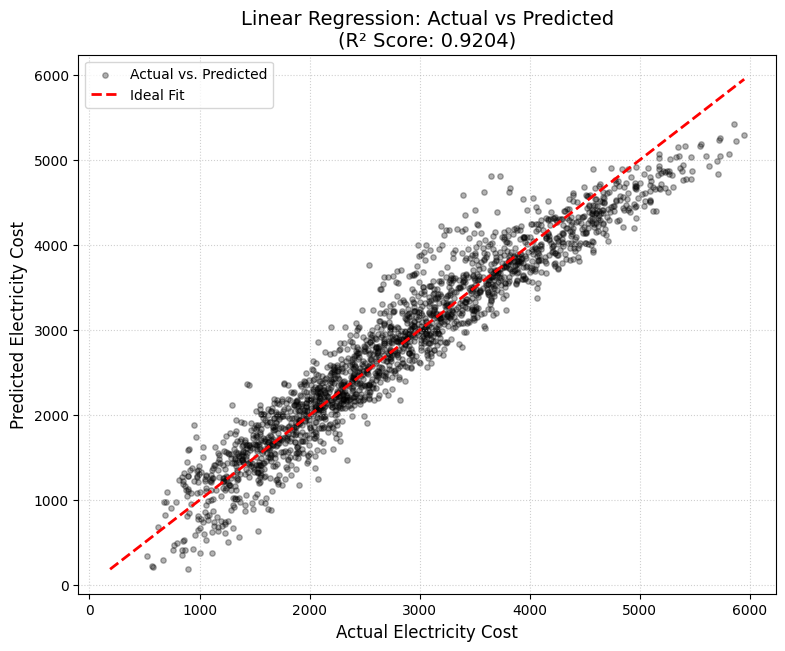

Metric               | Value
-----------------------------------
R² Score             | 0.9204
Intercept            | 279.6150

Feature Coefficients (Weight of Impact):
Site Area            |     0.6144
Water Consumption    |     0.0527
Utilisation Rate     |    10.2781
Resident Count       |     2.4539
Structure Type_Industrial |   601.6933
Structure Type_Mixed-Use |  -894.3292
Structure Type_Residential |  -187.9439


In [50]:

# 1. Define your useful features
features = [
    'site area', 
    'water consumption', 
    'resident count', 
    'utilisation rate'
]

# 2. Split data using your custom function
X_train, X_test, y_train, y_test = prepare_and_split_data(
    data_final, 
    target_col='electricity cost'
)

# 3. Create and Train the Multiple Linear Regression model
regr = LinearRegression()
regr.fit(X_train, y_train)


joblib.dump(regr, "linear_regression_model.pkl")

# 4. Predict on the test set
y_pred = regr.predict(X_test)

# 5. Plot: Parity Plot (Actual vs. Predicted)
plt.figure(figsize=(9, 7))

# Scatter plot of Actual vs Predicted
plt.scatter(y_test, y_pred, color='black', alpha=0.3, s=15, label='Actual vs. Predicted')

# Draw the identity line (Ideal 1:1 prediction)
limit = max(y_test.max(), y_pred.max())
start = min(y_test.min(), y_pred.min())
plt.plot([start, limit], [start, limit], color='red', linewidth=2, linestyle='--', label='Ideal Fit')

plt.xlabel('Actual Electricity Cost', fontsize=12)
plt.ylabel('Predicted Electricity Cost', fontsize=12)
plt.title(f'Linear Regression: Actual vs Predicted\n(R² Score: {r2_score(y_test, y_pred):.4f})', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 6. Print the Performance Metrics
print(f"{'Metric':<20} | {'Value'}")
print("-" * 35)
print(f"{'R² Score':<20} | {r2_score(y_test, y_pred):.4f}")
print(f"{'Intercept':<20} | {regr.intercept_:.4f}")

print("\nFeature Coefficients (Weight of Impact):")
for feat, coef in zip(X_train.columns, regr.coef_):
    print(f"{feat.title():<20} | {coef:>10.4f}")

## __Calculating Multiple Ridge Regression___

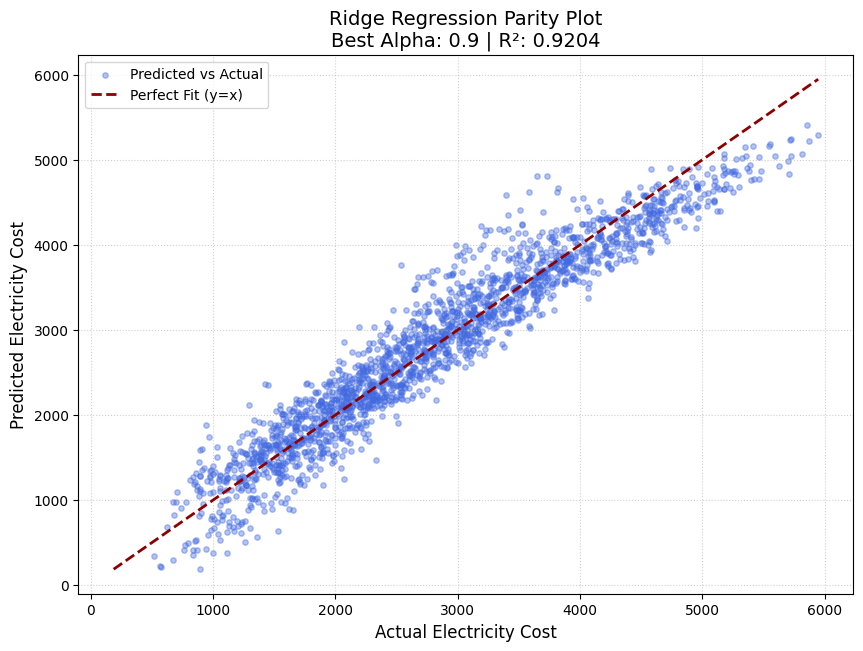

------------------------------
RESULTS SUMMARY
------------------------------
Best Alpha found: 0.9
R² score:        0.9204
Intercept:       279.1835

Feature Coefficients (Importance):
Structure Type_Mixed-Use :  -893.2018
Structure Type_Industrial:   601.2043
Structure Type_Residential:  -187.2516
Utilisation Rate         :    10.2783
Resident Count           :     2.4507
Site Area                :     0.6145
Water Consumption        :     0.0527


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# Define alpha values to try
alphas = np.arange(0.1, 5, 0.1)
# Create Ridge model
model = Ridge()
# Set up Grid Search to find best alpha
cv = GridSearchCV(estimator=model, param_grid={'alpha': alphas})
# Fit model on training data and predict on test data
cv.fit(X_train, y_train)

best_ridge = cv.best_estimator_
joblib.dump(best_ridge, "ridge_model.pkl")
 
y_pred = cv.predict(X_test)

# 4. Optimized Visualization: Parity Plot
# This solves the "too blue" problem by showing density instead of a messy line
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.4, s=15, label='Predicted vs Actual')

# Add the Identity Line (Perfect Match)
limit = max(y_test.max(), y_pred.max())
start = min(y_test.min(), y_pred.min())
plt.plot([start, limit], [start, limit], color='darkred', linestyle='--', linewidth=2, label='Perfect Fit (y=x)')

plt.xlabel('Actual Electricity Cost', fontsize=12)
plt.ylabel('Predicted Electricity Cost', fontsize=12)
plt.title(f"Ridge Regression Parity Plot\nBest Alpha: {cv.best_params_['alpha']} | R²: {r2_score(y_test, y_pred):.4f}", fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 5. Print the Results
print("-" * 30)
print(f"RESULTS SUMMARY")
print("-" * 30)
print(f"Best Alpha found: {cv.best_params_['alpha']}")
print(f"R² score:        {r2_score(y_test, y_pred):.4f}")
print(f"Intercept:       {cv.best_estimator_.intercept_:.4f}")
print("\nFeature Coefficients (Importance):")

# Sort coefficients by absolute value to show most important features first
coef_df = dict(zip(X_train.columns,  cv.best_estimator_.coef_))
for feat, coef in sorted(coef_df.items(), key=lambda item: abs(item[1]), reverse=True):
    print(f"{feat.title():<25}: {coef:>10.4f}")

## __Calculating Multiple Lasso Regression__

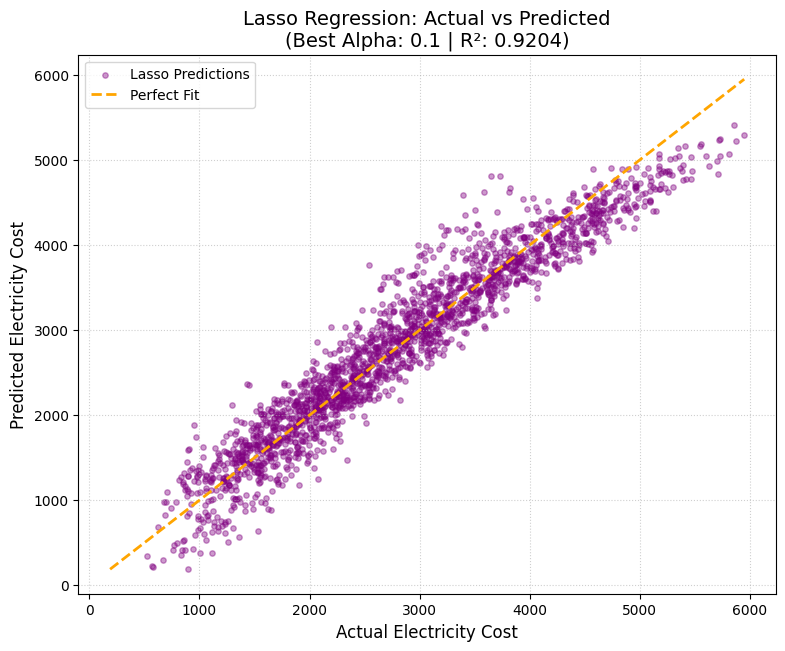

------------------------------
LASSO REGRESSION RESULTS
------------------------------
Best Alpha:  0.1
R² Score:    0.9204
Intercept:   278.8754

Feature Coefficients:
Site Area                :     0.6146
Water Consumption        :     0.0527
Utilisation Rate         :    10.2781
Resident Count           :     2.4485
Structure Type_Industrial:   601.0369
Structure Type_Mixed-Use :  -892.7536
Structure Type_Residential:  -186.5927


In [52]:

# 1. Define alpha values (Regularization strength)
alphas = np.arange(0.1, 5, 0.1)

# 2. Initialize Lasso model 
# Increased max_iter ensures the model converges even with small alphas
model = Lasso(max_iter=10000)

# 3. Setup GridSearchCV
cv = GridSearchCV(estimator=model, param_grid={'alpha': alphas})

# 4. Fit on Training Data and Predict on Test Data
# Using the X_train/y_train from your previous split
cv.fit(X_train, y_train)


best_lasso = cv.best_estimator_
joblib.dump(best_lasso, "lasso_model.pkl")

y_pred = cv.predict(X_test)

# 5. Plot: Parity Plot (Actual vs. Predicted)
plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_pred, color='purple', alpha=0.4, s=15, label='Lasso Predictions')

# Identity line
limit = max(y_test.max(), y_pred.max())
start = min(y_test.min(), y_pred.min())
plt.plot([start, limit], [start, limit], color='orange', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('Actual Electricity Cost', fontsize=12)
plt.ylabel('Predicted Electricity Cost', fontsize=12)
plt.title(f"Lasso Regression: Actual vs Predicted\n(Best Alpha: {cv.best_params_['alpha']} | R²: {r2_score(y_test, y_pred):.4f})", fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 6. Print the Results
print("-" * 30)
print(f"LASSO REGRESSION RESULTS")
print("-" * 30)
print(f"Best Alpha:  {cv.best_params_['alpha']}")
print(f"R² Score:    {r2_score(y_test, y_pred):.4f}")
print(f"Intercept:   {cv.best_estimator_.intercept_:.4f}")

print("\nFeature Coefficients:")
# Check if Lasso dropped any features (coefficient will be 0.0000)
for feat, coef in zip(X_train.columns, cv.best_estimator_.coef_):
    print(f"{feat.title():<25}: {coef:>10.4f}")

## __ElasticNet__

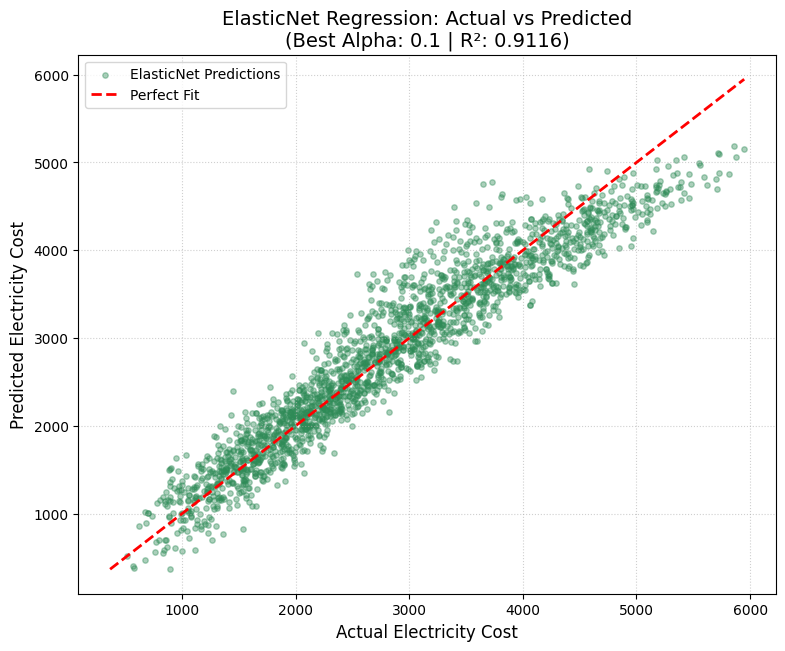

------------------------------
ELASTICNET RESULTS
------------------------------
Best Alpha:  0.1
R² Score:    0.9116
Intercept:   180.5000

Feature Coefficients:
Site Area                :     0.6352
Water Consumption        :     0.0544
Utilisation Rate         :    10.3209
Resident Count           :     1.6204
Structure Type_Industrial:   425.1947
Structure Type_Mixed-Use :  -596.1606
Structure Type_Residential:   -31.2808


In [53]:

# 1. Define alpha values (strength of regularization)
alphas = np.arange(0.1, 5, 0.1)

# 2. Initialize ElasticNet model
# max_iter=10000 helps the model find the solution for complex data
model = ElasticNet(max_iter=10000)

# 3. Setup GridSearchCV 
# We are searching for the best 'alpha'
cv = GridSearchCV( estimator=model, param_grid={'alpha': alphas}, scoring='r2'
)

# 4. Fit and predict using your pre-split data
cv.fit(X_train, y_train)

best_elastic = cv.best_estimator_
joblib.dump(best_elastic, "elasticnet_model.pkl")




y_pred = cv.predict(X_test)

# 5. Plot: Parity Plot (The fix for the "too blue" problem)
plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_pred, color='seagreen', alpha=0.4, s=15, label='ElasticNet Predictions')

# Identity line (Perfect prediction reference)
limit = max(y_test.max(), y_pred.max())
start = min(y_test.min(), y_pred.min())
plt.plot([start, limit], [start, limit], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('Actual Electricity Cost', fontsize=12)
plt.ylabel('Predicted Electricity Cost', fontsize=12)
plt.title(f"ElasticNet Regression: Actual vs Predicted\n(Best Alpha: {cv.best_params_['alpha']} | R²: {r2_score(y_test, y_pred):.4f})", fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 6. Outputs
best_model = cv.best_estimator_
print("-" * 30)
print(f"ELASTICNET RESULTS")
print("-" * 30)
print(f"Best Alpha:  {cv.best_params_['alpha']}")
print(f"R² Score:    {r2_score(y_test, y_pred):.4f}")
print(f"Intercept:   {best_model.intercept_:.4f}")

print("\nFeature Coefficients:")
for feat, coef in zip(X_train.columns, best_model.coef_):
    print(f"{feat.title():<25}: {coef:>10.4f}")

## __Gradient Boosting Regression__

site area            R2 score: 0.7692
water consumption    R2 score: 0.5228
resident count       R2 score: 0.5020
utilisation rate     R2 score: 0.0450


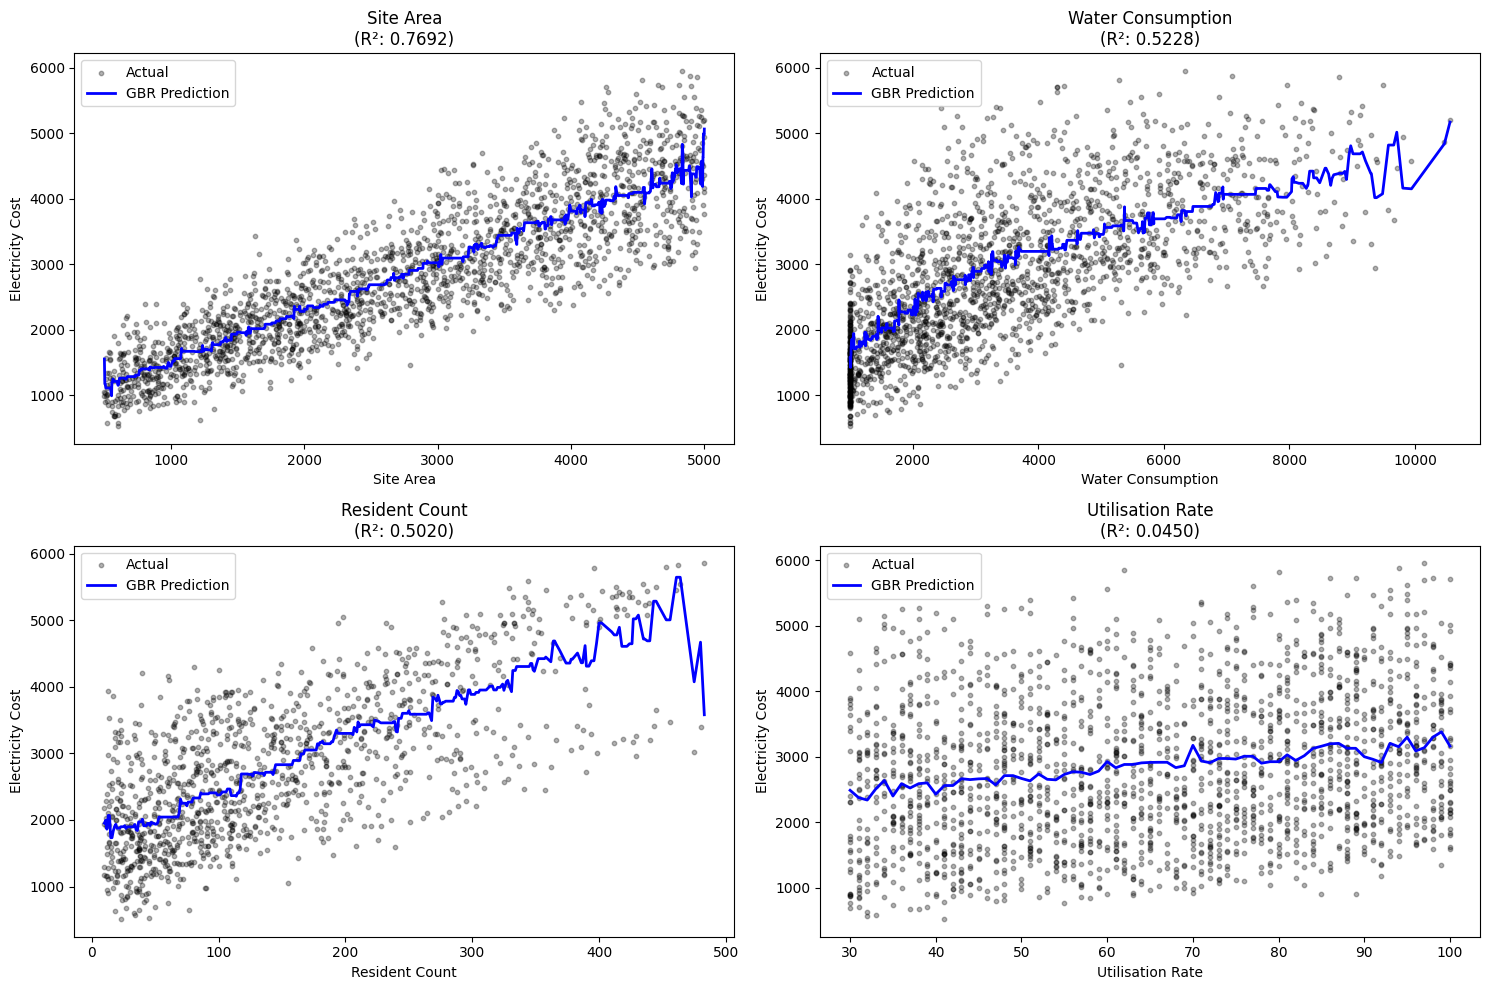

In [60]:

plot_features = ['site area', 'water consumption', 'resident count', 'utilisation rate']

plt.figure(figsize=(15, 10))
plot_count = 1

for feature in plot_features:
    data_tr = data_final[[feature, 'electricity cost']].dropna()
    data_tr = data_tr[data_tr[feature] != 0]

    # Split using your custom function (Returns X_train, X_test, y_train, y_test)
    X_train, X_test, y_train, y_test = prepare_and_split_data(data_tr, 'electricity cost')

    # Create and Train Gradient Boosting model
    regr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    regr.fit(X_train, y_train)

    # Predict
    y_pred = regr.predict(X_test)

    # 2. Plotting the non-linear relationship
    plt.subplot(2, 2, plot_count)
    
    # Sort the values for a smooth curve (Gradient Boosting isn't a straight line!)
    sorted_idx = X_test[feature].argsort()
    X_test_sorted = X_test.iloc[sorted_idx]
    y_pred_sorted = y_pred[sorted_idx]

    plt.scatter(X_test, y_test, color='black', alpha=0.3, s=10, label='Actual')
    plt.plot(X_test_sorted, y_pred_sorted, color='blue', linewidth=2, label='GBR Prediction')

    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel('Electricity Cost')
    plt.title(f"{feature.title()}\n(R²: {r2_score(y_test, y_pred):.4f})")
    plt.legend()

    print(f"{feature:<20} R2 score: {r2_score(y_test, y_pred):.4f}")
    plot_count += 1

plt.tight_layout()
plt.show()

## __Multiple Gradient Boosting Regression__

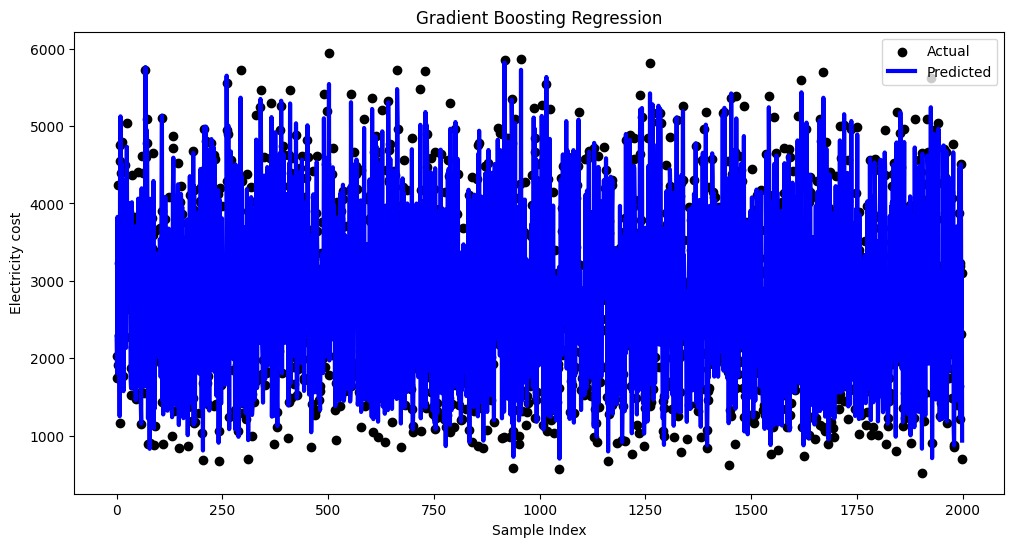

Gradient Boosting R²: 0.9607758340657556
Number of features used: 7


In [65]:
features = [
    'site area',
    'water consumption',
    'utilisation rate',
    'resident count',
    'structure type_Industrial',
    'structure type_Mixed-use',
    'structure type_Residential'
]

X = data_final[features]
y = data_final['electricity cost']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# SAVE MODEL (overwrite old one)
joblib.dump(gb_model, "gradient_boosting_model.pkl")

# Test
y_pred = gb_model.predict(X_test)
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test, color='black', label='Actual')
plt.plot(range(len(y_pred)), y_pred, color='blue', linewidth=3, label='Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Electricity cost')
plt.title('Gradient Boosting Regression')
plt.legend()
plt.show()
print("Gradient Boosting R²:", r2_score(y_test, y_pred))
print("Number of features used:", gb_model.n_features_in_)